# Table of Contents
Chunk 1 - Set up, data import and inspection

Chunk 2 - Target variable

Chunk 3 - Data preparation

Chunk 4 - Train and Evaluate Simple Decision Tree 1 to classify y

Chunk 5 - Train and Evaluate more complex Decision Tree 2 to classify y

Chunk 6 - Duration Removed Decision Tree 3 to predict y

Chunk 7 - Describe and compare the three models

# Chunk 1

In [1]:
import pandas as pd
import numpy as np
import sklearn
from sklearn import tree
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [4]:
raw_bankdata = pd.read_csv('https://raw.githubusercontent.com/matthewpecsok/4482_fall_2024/main/data/CD_additional_balanced.csv')
bank_data = raw_bankdata.copy()

In [9]:
bank_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9280 entries, 0 to 9279
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             9280 non-null   int64  
 1   job             9280 non-null   object 
 2   marital         9280 non-null   object 
 3   education       9280 non-null   object 
 4   default         9280 non-null   object 
 5   housing         9280 non-null   object 
 6   loan            9280 non-null   object 
 7   contact         9280 non-null   object 
 8   month           9280 non-null   object 
 9   day_of_week     9280 non-null   object 
 10  duration        9280 non-null   int64  
 11  campaign        9280 non-null   int64  
 12  pdays           9280 non-null   int64  
 13  previous        9280 non-null   int64  
 14  poutcome        9280 non-null   object 
 15  emp.var.rate    9280 non-null   float64
 16  cons.price.idx  9280 non-null   float64
 17  cons.conf.idx   9280 non-null   f

In [11]:
bank_data.shape

(9280, 21)

In [12]:
bank_data.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,9280.000000,9280.000000,9280.000000,9280.000000,9280.000000,9280.000000,9280.000000,9280.000000,9280.000000,9280.000000
mean,40.403448,387.361746,2.333297,887.282435,0.315302,-0.496272,93.479178,-40.218125,2.960209,5135.306487
std,12.062030,357.711742,2.334467,313.802415,0.700671,1.721204,0.634510,5.360642,1.890402,87.105317
min,17.000000,1.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,31.000000,145.000000,1.000000,999.000000,0.000000,-1.800000,92.893000,-42.700000,1.244000,5076.200000
50%,38.000000,265.000000,2.000000,999.000000,0.000000,-0.100000,93.444000,-41.800000,4.021000,5191.000000
75%,48.000000,528.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.959000,5228.100000
max,98.000000,4199.000000,39.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [14]:
bank_data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,41,blue-collar,divorced,basic.4y,unknown,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,yes
1,49,entrepreneur,married,university.degree,unknown,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,yes
2,49,technician,married,basic.9y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,yes
3,41,technician,married,professional.course,unknown,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,yes
4,45,blue-collar,married,basic.9y,unknown,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,yes


In [13]:
bank_data.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


# Chunk 2

In [26]:
target_counts = raw_bankdata['y'].value_counts()
target_proportions = raw_bankdata['y'].value_counts(normalize=True)

print("Count of each class of target variable:")
display(target_counts)

print("\nProportion of each class of target variable:")
display(target_proportions)

Count of each class of target variable:


,count
y,
yes,4640
no,4640



Proportion of each class of target variable:


,proportion
y,
yes,0.5
no,0.5


Is the distribution of the target variable imbalanced?

* No. There is the same number of instances in for each class.

In [18]:
y_target = bank_data.pop('y')

# Chunk 3

Categorical features:
* poutcome
* day_of_the_week
* month
* contact
* job
* marital
* education
* default
* housing
* loan

Quantitative features:
* duration
* campaign
* pdays
* previous
* emp.var.rate
* cons.price.idx
* cons.conf.idx
* euribor3m
* nr.employed



In [29]:
categorical_cols = ['poutcome', 'day_of_week', 'month', 'contact', 'job', 'marital', 'education', 'default', 'housing', 'loan']

for col in categorical_cols:
    print(f"Distribution of '{col}':")
    display(bank_data[col].value_counts())
    print("\n")

Distribution of 'poutcome':


,count
poutcome,
nonexistent,7244
failure,1074
success,962




Distribution of 'day_of_week':


,count
day_of_week,
thu,2000
wed,1861
mon,1846
tue,1810
fri,1763




Distribution of 'month':


...

,count
default,
no,7824
unknown,1456




Distribution of 'housing':


,count
housing,
yes,4951
no,4104
unknown,225




Distribution of 'loan':


,count
loan,
no,7688
yes,1367
unknown,225


In [36]:
bank_data = bank_data.astype({"poutcome":"category",
                              "day_of_week":"category",
                              "month":"category",
                              "contact":"category",
                              "job":"category",
                              "marital":"category",
                              "education":"category",
                              "default":"category",
                              "housing":"category",
                              "loan":"category"})
bank_data.dtypes

,0
age,int64
job,category
marital,category
education,category
default,category
housing,category
loan,category
contact,category
month,category
day_of_week,category


In [40]:
bank_data_encoded_x = pd.get_dummies(bank_data)
bank_data_encoded_X.head()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,month_oct,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success
0,41,1575,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,False,False,True,False,False,False,False,True,False
1,49,1042,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,False,False,True,False,False,False,False,True,False
2,49,1467,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,False,False,True,False,False,False,False,True,False
3,41,579,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,False,False,True,False,False,False,False,True,False
4,45,461,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,False,False,True,False,False,False,False,True,False


# Chunk 4

In [41]:
random_state = 42
tree_model_1 = tree.DecisionTreeClassifier(random_state=random_state, ccp_alpha= 0.1)
tree_model_1

DecisionTreeClassifier(ccp_alpha=0.1, random_state=42)

In [42]:
tree_model_1 = tree_model_1.fit(bank_data_encoded_x, y_target)

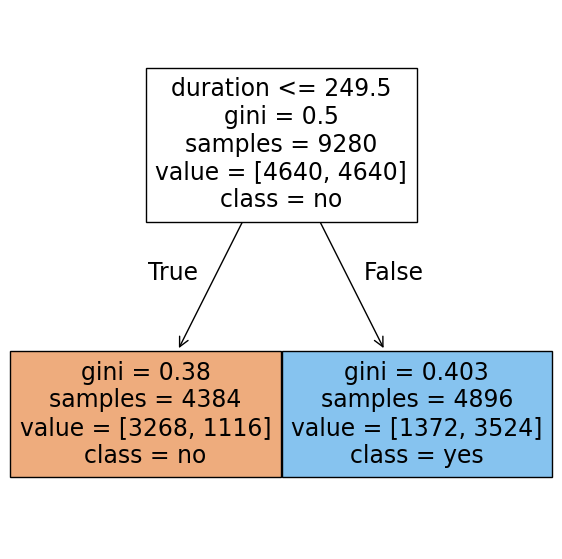

In [49]:
fig1 = plt.figure(figsize=(7,7))
tree.plot_tree(tree_model_1, filled=True, feature_names=bank_data_encoded_x.columns.to_list(), class_names=['no', 'yes'])
plt.show()

task 4.b: The root of the tree is duration. the splitting value is 249.5. If it is less than 249.5, then the class = no. we would predict that the client has not subscribed a certified term deposit (CD). If it is greater than 249.5, then it is class-yes. we would predict that the client has subscribed a certified term deposit (CD).

task 4.c: The number of misclassifications for those who have not subscribed a certified term deposit (class = no) is 1116. The number of misclassifications for those who have subscribed to a certified term deposit (class = yes) is 1372. The equation is 1116 + 1372 = 2488. Without the split value, the model would have made 4640 misclassifications, which is 2152 fewer misclassifications, calculated with 4640 - 2488 = 2152.

task 4.d: entropy = 1.0 for the root node because it's would have incorrectly classified all class = yes instances as class = no. Since everything is no, entropy = 1.0.

In [52]:
model_1_pred = tree_model_1.predict(bank_data_encoded_x)
model_1_pred

array(['yes', 'yes', 'yes', ..., 'no', 'no', 'no'], dtype=object)

In [54]:
model_1_cf = confusion_matrix(y_true= y_target, y_pred= model_1_pred)
model_1_cf

array([[3268, 1372],
       [1116, 3524]])

In [55]:
print(metrics.classification_report(y_target, model_1_pred))

              precision    recall  f1-score   support

          no       0.75      0.70      0.72      4640
         yes       0.72      0.76      0.74      4640

    accuracy                           0.73      9280
   macro avg       0.73      0.73      0.73      9280
weighted avg       0.73      0.73      0.73      9280



# Chunk 5

In [98]:
random_state = 42
tree_model_2 = tree.DecisionTreeClassifier(random_state=random_state, ccp_alpha= 0.006)
tree_model_2

DecisionTreeClassifier(ccp_alpha=0.006, random_state=42)

In [99]:
tree_model_2 = tree_model_2.fit(bank_data_encoded_x, y_target)

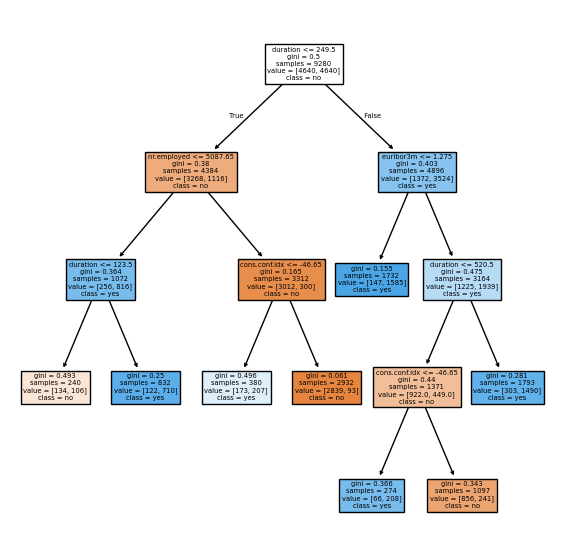

In [100]:
fig2 = plt.figure(figsize=(7,7))
tree.plot_tree(tree_model_2, filled=True, feature_names=bank_data_encoded_x.columns.to_list(), class_names=['no', 'yes'])
plt.show()

In [101]:
model_2_pred = tree_model_2.predict(bank_data_encoded_x)
model_2_pred

array(['yes', 'yes', 'yes', ..., 'no', 'no', 'no'], dtype=object)

In [102]:
model_2_cf = confusion_matrix(y_true= y_target, y_pred= model_2_pred)
model_2_cf

array([[3829,  811],
       [ 440, 4200]])

In [103]:
print(metrics.classification_report(y_target, model_2_pred))

              precision    recall  f1-score   support

          no       0.90      0.83      0.86      4640
         yes       0.84      0.91      0.87      4640

    accuracy                           0.87      9280
   macro avg       0.87      0.87      0.86      9280
weighted avg       0.87      0.87      0.86      9280



# Chunk 6

In [175]:
bank_data_encoded_x_no_duration = bank_data_encoded_x.drop('duration', axis = 1)

In [176]:
random_state = 42
tree_model_3 = tree.DecisionTreeClassifier(random_state=random_state, ccp_alpha= 0.002)
tree_model_3

DecisionTreeClassifier(ccp_alpha=0.002, random_state=42)

In [181]:
tree_model_3 = tree_model_3.fit(bank_data_encoded_x_no_duration, y_target)

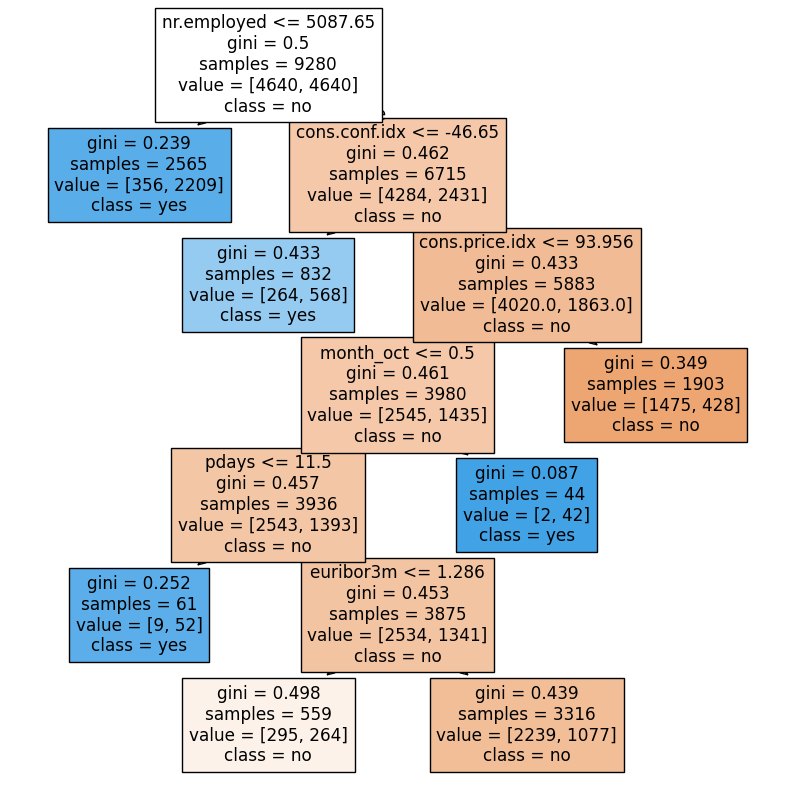

In [182]:
fig3 = plt.figure(figsize=(10,10))
tree.plot_tree(tree_model_3, filled=True, feature_names=bank_data_encoded_x_no_duration.columns.to_list(), class_names=['no', 'yes'])
plt.show()

In [183]:
model_3_pred = tree_model_3.predict(bank_data_encoded_x_no_duration)
model_3_pred

array(['no', 'no', 'no', ..., 'yes', 'no', 'no'], dtype=object)

In [184]:
model_3_cf = confusion_matrix(y_true= y_target, y_pred= model_3_pred)
model_3_cf

array([[4009,  631],
       [1769, 2871]])

In [185]:
print(metrics.classification_report(y_target, model_3_pred))

              precision    recall  f1-score   support

          no       0.69      0.86      0.77      4640
         yes       0.82      0.62      0.71      4640

    accuracy                           0.74      9280
   macro avg       0.76      0.74      0.74      9280
weighted avg       0.76      0.74      0.74      9280



Looking at model 2, accuracy = 0.87 and f1-score = 86. For model 3, accuracy = 0.76 and f1-score = 0.74. I think this is because duration was the best predictor of whether a client would subscribe to a certified term deposit. Because we removed that feature, the model has to go to the next best predictor, which is why the performance for model 3 would have dropped.

# Chunk 7

In [186]:
print(metrics.classification_report(y_target, model_1_pred))

              precision    recall  f1-score   support

          no       0.75      0.70      0.72      4640
         yes       0.72      0.76      0.74      4640

    accuracy                           0.73      9280
   macro avg       0.73      0.73      0.73      9280
weighted avg       0.73      0.73      0.73      9280



In [ ]:
print(metrics.classification_report(y_target, model_2_pred))

              precision    recall  f1-score   support

          no       0.90      0.83      0.86      4640
         yes       0.84      0.91      0.87      4640

    accuracy                           0.87      9280
   macro avg       0.87      0.87      0.86      9280
weighted avg       0.87      0.87      0.86      9280



In [ ]:
print(metrics.classification_report(y_target, model_3_pred))

              precision    recall  f1-score   support

          no       0.69      0.86      0.77      4640
         yes       0.82      0.62      0.71      4640

    accuracy                           0.74      9280
   macro avg       0.76      0.74      0.74      9280
weighted avg       0.76      0.74      0.74      9280



Looking at the accuracy and F1 score metrics above, we see that model 2 performed the best with accuracy = 0.87 and an f1-score of 0.86. Models 1 and 2 both used the best predictor, duration as their root node; however, model 2 did better because it had more branch nodes to increase the purity of the data and reduce uncertainty. Compared to models  3 which lacks the duration feature and model 3 which lacks the nr.employed feature, model 2 has better performance because is able to utilize both. Looking at the CCP, you can see that model 3 has the least pruning, likely to a bit more overfitting, while model 1 has been pruned a ton.

In [ ]:
!jupyter nbconvert --to html PATH_TO_THE_NOTEBOOK_IN_COLAB.ipynb